# Retail Sales Anomaly Detection Using Unsupervised Learning

## Project Overview
This project focuses on identifying unusual transaction patterns in retail pizza sales data using unsupervised learning techniques. The objective is to detect abnormal purchasing behavior, atypical revenue patterns, and rare combinations of sales characteristics that may provide useful business insights.

The dataset contains transaction-level information such as quantity sold, unit price, total price, pizza category, pizza size, and order timestamps. These variables make it possible to explore anomalies from both an operational and commercial perspective.

## Business Problem
Retail transaction data often contains unusual observations that may reflect exceptional customer behavior, operational irregularities, pricing inconsistencies, or rare demand patterns. Detecting these anomalies can help businesses monitor sales activity, identify unusual orders, and better understand extreme transaction behavior.

In this project, anomaly detection is used to analyze pizza sales transactions and uncover patterns that differ significantly from normal sales activity.

## Import Libraries
The first step is to import the libraries required for data manipulation, visualization, preprocessing, and anomaly detection modeling. These tools will support the full workflow, from initial exploration to model development.

In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Download the Dataset
The dataset is downloaded directly from Kaggle using `kagglehub`. This ensures that the project remains reproducible and that the latest available version of the dataset is used.

In [2]:
# ============================================
# 2. DOWNLOAD DATASET FROM KAGGLE
# ============================================

import kagglehub

# Download latest version
path = kagglehub.dataset_download("avijitjana101/dominos-predictive-purchase-order-system")

print("Path to dataset files:", path)

100%|██████████| 2.28M/2.28M [00:00<00:00, 11.4MB/s]

Extracting files...
Path to dataset files: C:\Users\MSI RYZEN 5\.cache\kagglehub\datasets\avijitjana101\dominos-predictive-purchase-order-system\versions\1


## Inspect Downloaded Files
After downloading the dataset, the next step is to inspect the files included in the folder. This allows us to identify the main transactional dataset and any complementary files that may enrich the analysis.

In [3]:
# ============================================
# 3. LIST FILES IN THE DOWNLOADED FOLDER
# ============================================

files = os.listdir(path)
print("Files found:")
for file in files:
    print(file)

Files found:
Pizza_ingredients.xlsx
Pizza_Sale.xlsx


## Load the Main Sales Dataset
The main file used in this project is the sales transaction dataset. This file contains the variables needed for anomaly detection, such as order identifiers, quantity, prices, category, size, and timestamps.

In [12]:
# ============================================
# 4. LOAD MAIN SALES DATA
# ============================================

sales_file = os.path.join(path, "Pizza_Sale.xlsx")
ingredients_file = os.path.join(path, "Pizza_ingredients.xlsx")

print("Sales file:", sales_file)
print("Ingredients file:", ingredients_file)

df = pd.read_excel(sales_file, engine="openpyxl")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Sales file: C:\Users\MSI RYZEN 5\.cache\kagglehub\datasets\avijitjana101\dominos-predictive-purchase-order-system\versions\1\Pizza_Sale.xlsx
Ingredients file: C:\Users\MSI RYZEN 5\.cache\kagglehub\datasets\avijitjana101\dominos-predictive-purchase-order-system\versions\1\Pizza_ingredients.xlsx
Dataset loaded successfully.
Shape: (48620, 12)


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01 00:00:00,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01 00:00:00,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01 00:00:00,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01 00:00:00,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01 00:00:00,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


## Clean Column Names
Before starting the analysis, column names are standardized by converting them to lowercase and replacing spaces with underscores. This makes the dataset easier to work with and improves code readability.

In [13]:
# ============================================
# 5. CLEAN COLUMN NAMES
# ============================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^\w]", "", regex=True)
)

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['pizza_id', 'order_id', 'pizza_name_id', 'quantity', 'order_date', 'order_time', 'unit_price', 'total_price', 'pizza_size', 'pizza_category', 'pizza_ingredients', 'pizza_name']


## Initial Data Inspection
A first inspection of the dataset is performed to understand its structure, size, data types, and overall quality. This step is essential to identify missing values, duplicated rows, and the main variables available for the analysis.

In [14]:
# ============================================
# 6. BASIC DATA CHECK
# ============================================

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

display(df.head())

Shape: (48620, 12)

Missing values:
pizza_id              0
order_id              0
pizza_name_id        16
quantity              0
order_date            0
order_time            0
unit_price            0
total_price           7
pizza_size            0
pizza_category       23
pizza_ingredients    13
pizza_name            7
dtype: int64

Duplicate rows: 0

Data types:
pizza_id               int64
order_id               int64
pizza_name_id         object
quantity               int64
order_date            object
order_time            object
unit_price           float64
total_price          float64
pizza_size            object
pizza_category        object
pizza_ingredients     object
pizza_name            object
dtype: object


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,2015-01-01 00:00:00,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,2015-01-01 00:00:00,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,2015-01-01 00:00:00,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,2015-01-01 00:00:00,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,2015-01-01 00:00:00,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


## Initial Findings
The dataset contains **48,620 rows** and **12 columns**, which provides a strong foundation for anomaly detection analysis. The data includes key transaction-level variables such as:

- `quantity`
- `unit_price`
- `total_price`
- `order_date`
- `order_time`
- `pizza_size`
- `pizza_category`

The dataset shows **no duplicated rows** and only a small number of missing values, indicating that the data quality is relatively strong for this type of analysis.

## Convert Date and Time Variables
The `order_date` and `order_time` columns are converted into proper datetime formats. This step is necessary to enable time-based feature engineering and to explore sales behavior across days, hours, and weekends.

In [15]:
# ============================================
# 7. CONVERT DATE AND TIME COLUMNS
# ============================================

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["order_time"] = pd.to_datetime(df["order_time"], format="%H:%M:%S", errors="coerce")

print(df[["order_date", "order_time"]].dtypes)
display(df[["order_date", "order_time"]].head())

order_date    datetime64[ns]
order_time    datetime64[ns]
dtype: object


,order_date,order_time
0,2015-01-01,1900-01-01 11:38:36
1,2015-01-01,1900-01-01 11:57:40
2,2015-01-01,1900-01-01 11:57:40
3,2015-01-01,1900-01-01 11:57:40
4,2015-01-01,1900-01-01 11:57:40


## Handle Missing Values
Because the number of missing values is very small relative to the size of the dataset, rows with missing values in key variables are removed. This helps preserve data quality without significantly reducing the sample size.

In [16]:
# ============================================
# 8. HANDLE MISSING VALUES
# ============================================

print("Rows before cleaning:", df.shape[0])

df = df.dropna(subset=["total_price", "pizza_name", "pizza_category", "pizza_name_id", "pizza_ingredients"])

print("Rows after cleaning:", df.shape[0])
print("Missing values after cleaning:\n")
print(df.isnull().sum())

Rows before cleaning: 48620
Rows after cleaning: 48554
Missing values after cleaning:

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64


## Feature Engineering: Time-Based Variables
New variables are created from the order date and time to capture temporal sales patterns. These include:

- `year`
- `month`
- `day`
- `day_of_week`
- `hour`
- `minute`
- `is_weekend`

These features are useful for detecting whether certain transactions are unusual relative to normal sales behavior at different times.

In [17]:
# ============================================
# 9. FEATURE ENGINEERING - TIME FEATURES
# ============================================

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["day"] = df["order_date"].dt.day
df["day_of_week"] = df["order_date"].dt.day_name()

df["hour"] = df["order_time"].dt.hour
df["minute"] = df["order_time"].dt.minute
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

print("New columns added:")
display(df.head())

New columns added:


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,year,month,day,day_of_week,hour,minute,is_weekend
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,2015,1,1,Thursday,11,38,0
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,1,1,Thursday,11,57,0
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,2015,1,1,Thursday,11,57,0
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,2015,1,1,Thursday,11,57,0
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,2015,1,1,Thursday,11,57,0


## Post-Cleaning Summary
After cleaning the dataset and converting the time variables, the data is re-evaluated to confirm that it is ready for exploratory analysis and model development. This step helps verify that missing values have been handled correctly and that the newly created features are valid.

In [18]:
# ============================================
# 10. POST-CLEANING SUMMARY
# ============================================

print("Final shape:", df.shape)

print("\nNumerical summary:")
display(df.describe())

print("\nCategorical summary:")
display(df.describe(include="object"))

Final shape: (48554, 19)

Numerical summary:


,pizza_id,order_id,quantity,order_date,order_time,unit_price,total_price,year,month,day,hour,minute,is_weekend
count,"48,554.00","48,554.00","48,554.00",48554,48554,"48,554.00","48,554.00","48,554.00","48,554.00","48,554.00","48,554.00","48,554.00","48,554.00"
mean,"24,342.87","10,715.73",1.02,2015-06-29 00:59:45.616015104,1900-01-01 16:24:50.723071232,16.49,16.82,"2,015.00",6.44,15.50,15.91,29.65,0.27
min,1.00,1.00,1.00,2015-01-01 00:00:00,1900-01-01 09:52:21,9.75,9.75,"2,015.00",1.00,1.00,9.00,0.00,0.00
25%,"12,205.25","5,360.25",1.00,2015-03-30 00:00:00,1900-01-01 13:24:44,12.75,12.75,"2,015.00",3.00,8.00,13.00,15.00,0.00
50%,"24,343.50","10,702.00",1.00,2015-06-28 00:00:00,1900-01-01 16:33:35.500000,16.50,16.50,"2,015.00",6.00,15.00,16.00,30.00,0.00
75%,"36,481.75","16,107.75",1.00,2015-09-29 00:00:00,1900-01-01 18:55:18.249999872,20.25,20.50,"2,015.00",9.00,23.00,18.00,45.00,1.00
max,"48,620.00","21,350.00",4.00,2015-12-31 00:00:00,1900-01-01 23:05:52,35.95,83.00,"2,015.00",12.00,31.00,23.00,59.00,1.00
std,"14,017.56","6,172.21",0.14,NaN,NaN,3.62,4.44,0.00,3.44,8.78,3.15,17.31,0.45



Categorical summary:


,pizza_name_id,pizza_size,pizza_category,pizza_ingredients,pizza_name,day_of_week
count,48554,48554,48554,48554,48554,48554
unique,91,5,4,32,32,7
top,big_meat_s,L,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,Friday
freq,1810,18496,14559,2416,2416,7704


## Exploratory Data Analysis
Exploratory data analysis is conducted to better understand the distribution of the main numerical variables and the temporal behavior of transactions. This stage helps identify potential outliers, unusual concentrations, and relevant sales patterns that may later support anomaly detection.

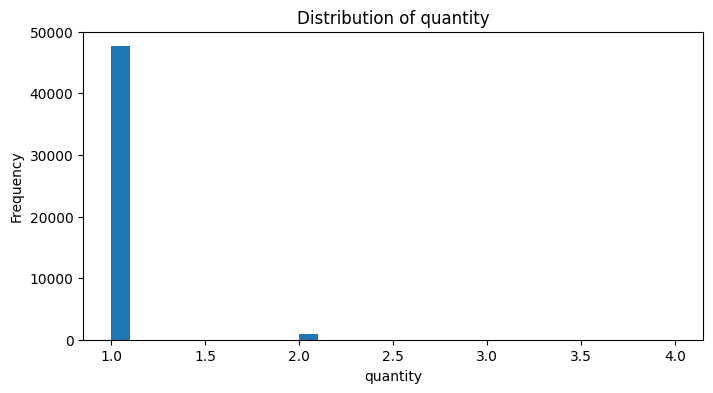

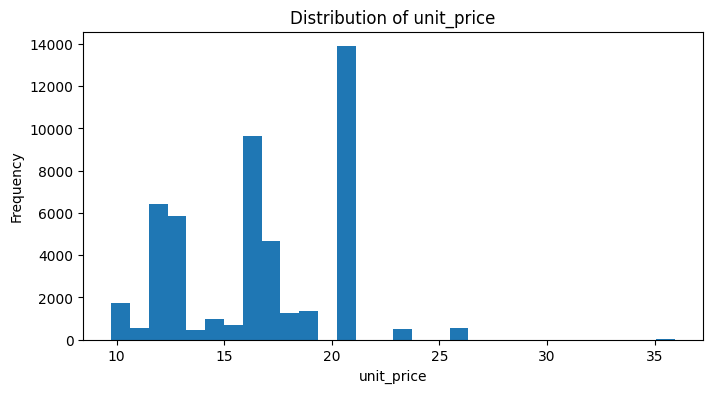

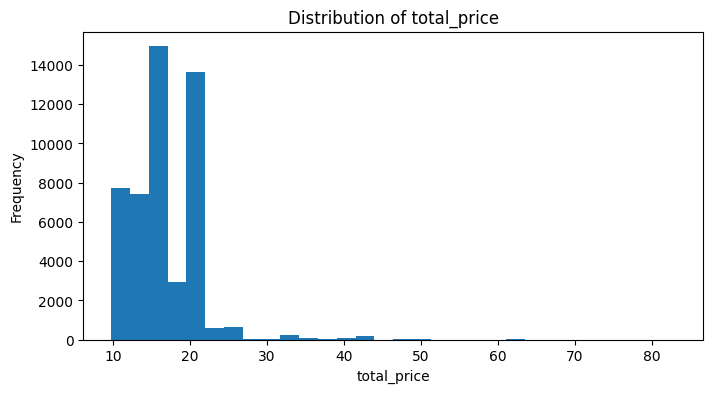

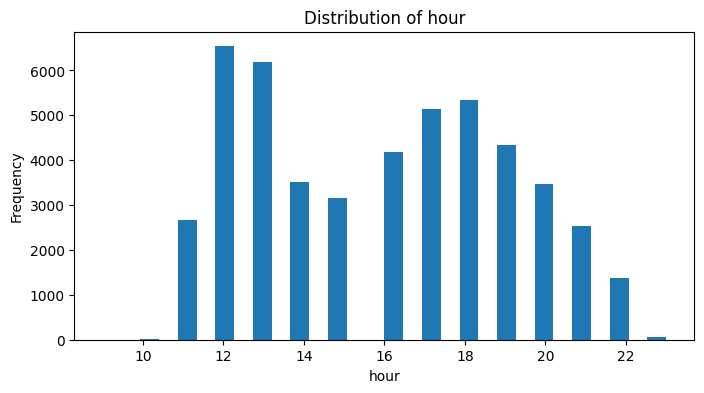

In [19]:
# ============================================
# 11. DISTRIBUTION OF NUMERICAL VARIABLES
# ============================================

num_cols = ["quantity", "unit_price", "total_price", "hour"]

for col in num_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

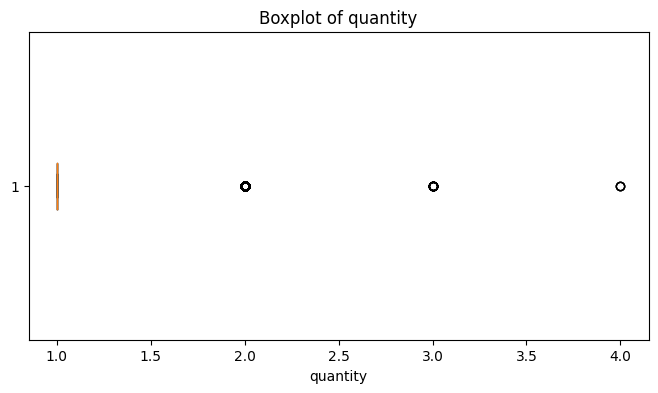

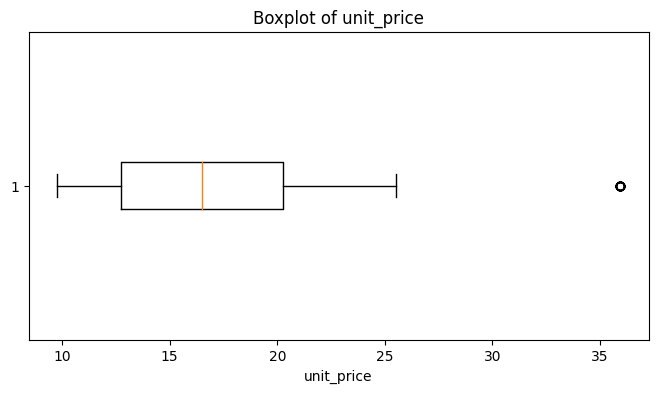

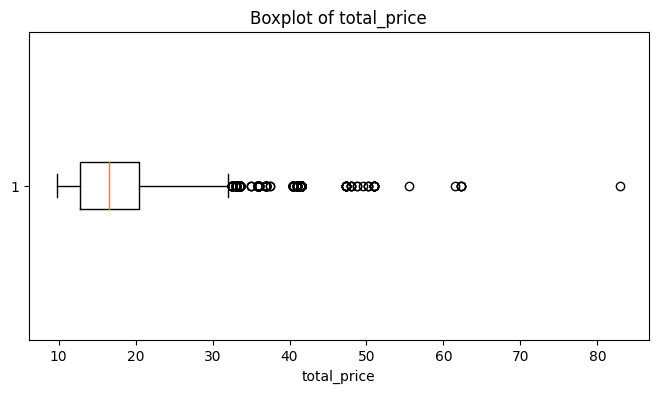

In [20]:
# ============================================
# 12. BOXPLOTS FOR KEY NUMERICAL VARIABLES
# ============================================

for col in ["quantity", "unit_price", "total_price"]:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

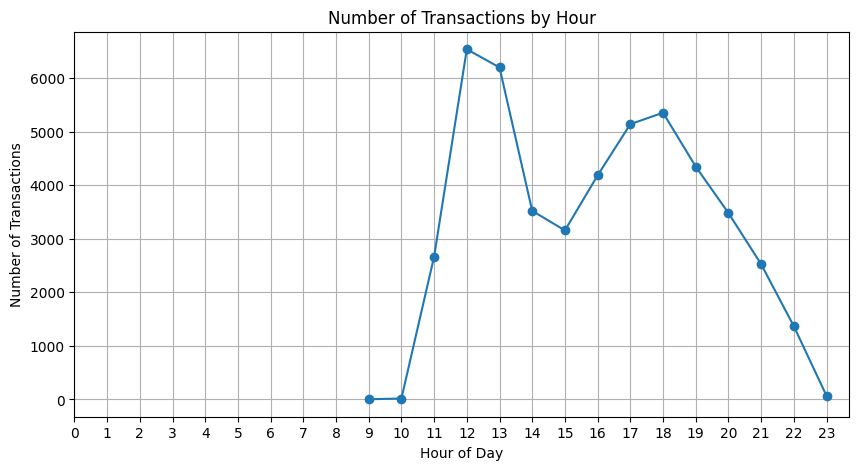

In [21]:
# ============================================
# 13. SALES VOLUME BY HOUR
# ============================================

hourly_orders = df.groupby("hour")["order_id"].count()

plt.figure(figsize=(10, 5))
plt.plot(hourly_orders.index, hourly_orders.values, marker="o")
plt.title("Number of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

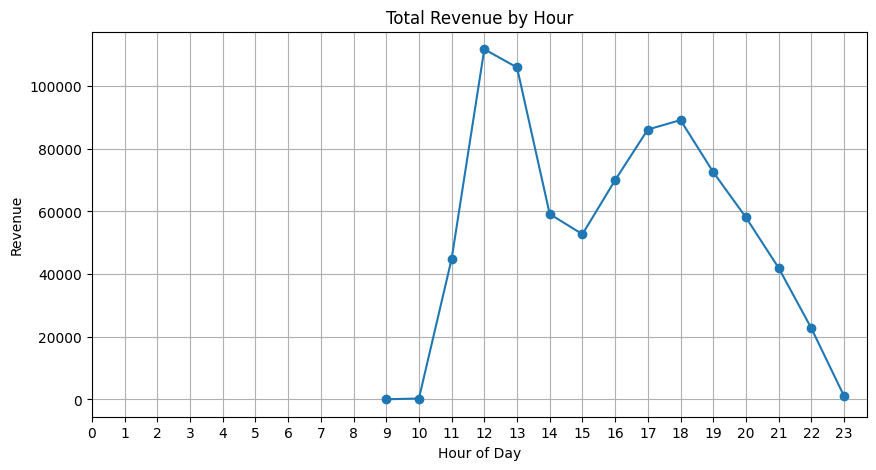

In [22]:
# ============================================
# 14. REVENUE BY HOUR
# ============================================

hourly_revenue = df.groupby("hour")["total_price"].sum()

plt.figure(figsize=(10, 5))
plt.plot(hourly_revenue.index, hourly_revenue.values, marker="o")
plt.title("Total Revenue by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

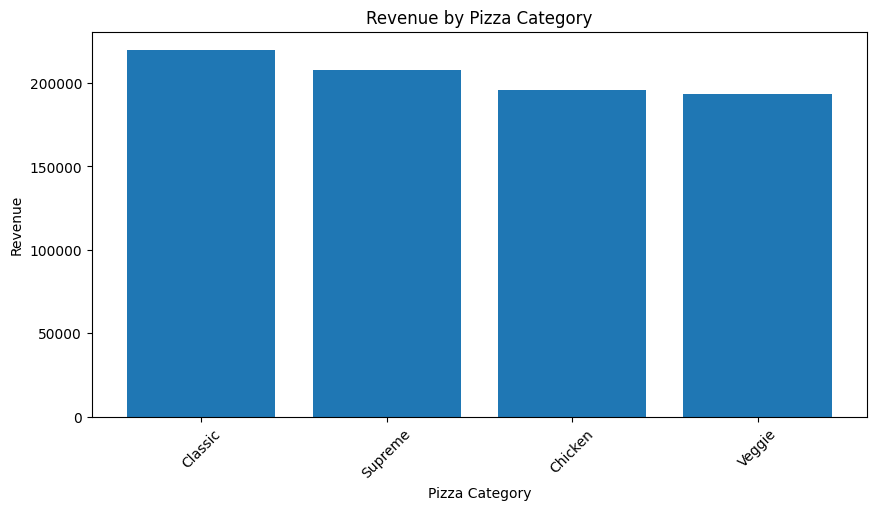

In [23]:
# ============================================
# 15. SALES BY PIZZA CATEGORY
# ============================================

category_sales = df.groupby("pizza_category")["total_price"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Revenue by Pizza Category")
plt.xlabel("Pizza Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

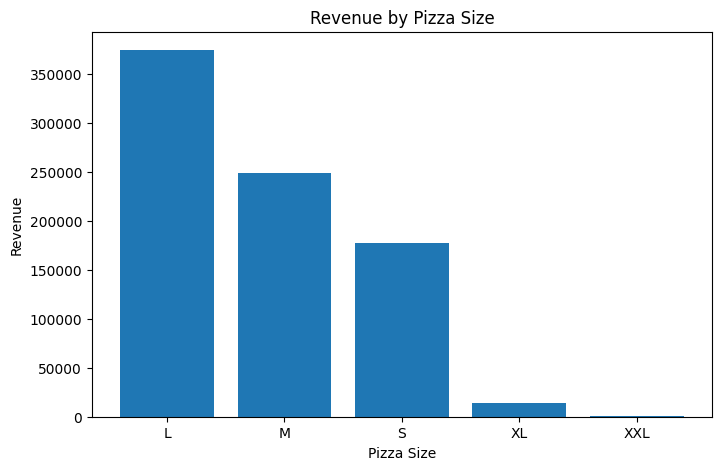

In [24]:
# ============================================
# 16. SALES BY PIZZA SIZE
# ============================================

size_sales = df.groupby("pizza_size")["total_price"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(size_sales.index, size_sales.values)
plt.title("Revenue by Pizza Size")
plt.xlabel("Pizza Size")
plt.ylabel("Revenue")
plt.show()

In [25]:
# ============================================
# 17. TOP TRANSACTIONS BY TOTAL PRICE
# ============================================

top_transactions = df.sort_values(by="total_price", ascending=False)[
    ["order_id", "pizza_name", "quantity", "unit_price", "total_price", "pizza_size", "pizza_category", "order_date", "hour"]
].head(10)

display(top_transactions)

,order_id,pizza_name,quantity,unit_price,total_price,pizza_size,pizza_category,order_date,hour
35496,15674,The California Chicken Pizza,4,20.75,83.00,L,Chicken,2015-09-19,14
183,78,The Spicy Italian Pizza,3,20.75,62.25,L,Supreme,2015-02-01,12
38819,17112,The Barbecue Chicken Pizza,3,20.75,62.25,L,Chicken,2015-10-17,12
18317,8040,The Thai Chicken Pizza,3,20.75,62.25,L,Chicken,2015-05-15,14
37638,16619,The Prosciutto and Arugula Pizza,3,20.75,62.25,L,Supreme,2015-08-10,12
35627,15728,The Italian Capocollo Pizza,3,20.50,61.50,L,Classic,2015-09-20,12
41558,18286,The Five Cheese Pizza,3,18.50,55.50,L,Veggie,2015-08-11,13
12414,5452,The Greek Pizza,2,25.50,51.00,XL,Classic,2015-02-04,12
46788,20543,The Greek Pizza,2,25.50,51.00,XL,Classic,2015-12-15,17
45519,19988,The Greek Pizza,2,25.50,51.00,XL,Classic,2015-06-12,14


## Feature Engineering for Anomaly Detection
To improve the anomaly detection process, additional features are created to capture deviations from normal behavior. These include:

- average total price by category
- deviation from category average price
- average quantity by pizza size
- deviation from size average quantity
- average total price by hour
- deviation from hourly average price

These variables help the model distinguish between normal and unusual transactions more effectively by incorporating business context into the feature space.

In [26]:
# ============================================
# 18. ADD FEATURES FOR ANOMALY DETECTION
# ============================================

# Average total price by category
df["category_avg_price"] = df.groupby("pizza_category")["total_price"].transform("mean")

# Price deviation from category average
df["price_deviation_from_category"] = df["total_price"] - df["category_avg_price"]

# Average quantity by pizza size
df["size_avg_quantity"] = df.groupby("pizza_size")["quantity"].transform("mean")

# Quantity deviation from size average
df["quantity_deviation_from_size"] = df["quantity"] - df["size_avg_quantity"]

# Average hourly revenue proxy at row level
df["hour_avg_total_price"] = df.groupby("hour")["total_price"].transform("mean")

# Deviation from hourly average
df["price_deviation_from_hour"] = df["total_price"] - df["hour_avg_total_price"]

display(df.head())

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,year,month,day,day_of_week,hour,minute,is_weekend,category_avg_price,price_deviation_from_category,size_avg_quantity,quantity_deviation_from_size,hour_avg_total_price,price_deviation_from_hour
0,1,1,hawaiian_m,1,2015-01-01,1900-01-01 11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza,2015,1,1,Thursday,11,38,0,15.10,-1.85,1.02,-0.02,16.82,-3.57
1,2,2,classic_dlx_m,1,2015-01-01,1900-01-01 11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza,2015,1,1,Thursday,11,57,0,15.10,0.90,1.02,-0.02,16.82,-0.82
2,3,2,five_cheese_l,1,2015-01-01,1900-01-01 11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza,2015,1,1,Thursday,11,57,0,16.92,1.58,1.02,-0.02,16.82,1.68
3,4,2,ital_supr_l,1,2015-01-01,1900-01-01 11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza,2015,1,1,Thursday,11,57,0,17.68,3.07,1.02,-0.02,16.82,3.93
4,5,2,mexicana_m,1,2015-01-01,1900-01-01 11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza,2015,1,1,Thursday,11,57,0,16.92,-0.92,1.02,-0.02,16.82,-0.82


## Review of Engineered Features
The newly created features are summarized to confirm that they were generated correctly and to assess their scale and variability. This step is important before moving into preprocessing and anomaly detection modeling.

In [27]:
# ============================================
# 19. CHECK ENGINEERED FEATURES
# ============================================

engineered_cols = [
    "quantity",
    "unit_price",
    "total_price",
    "hour",
    "is_weekend",
    "category_avg_price",
    "price_deviation_from_category",
    "size_avg_quantity",
    "quantity_deviation_from_size",
    "hour_avg_total_price",
    "price_deviation_from_hour"
]

display(df[engineered_cols].describe())

,quantity,unit_price,total_price,hour,is_weekend,category_avg_price,price_deviation_from_category,size_avg_quantity,quantity_deviation_from_size,hour_avg_total_price,price_deviation_from_hour
count,"48,554.00","48,554.00","48,554.00","48,554.00","48,554.00","48,554.00","48,554.00","48,554.00","48,554.00","48,554.00","48,554.00"
mean,1.02,16.49,16.82,15.91,0.27,16.82,-0.00,1.02,0.00,16.82,0.00
std,0.14,3.62,4.44,3.15,0.45,1.20,4.27,0.00,0.14,0.18,4.43
min,1.00,9.75,9.75,9.00,0.00,15.10,-5.43,1.00,-0.02,16.49,-7.35
25%,1.00,12.75,12.75,13.00,0.00,15.10,-3.10,1.02,-0.02,16.70,-4.16
50%,1.00,16.50,16.50,16.00,0.00,16.92,-0.92,1.02,-0.02,16.74,-0.31
75%,1.00,20.25,20.50,18.00,1.00,17.68,2.64,1.02,-0.02,17.10,3.62
max,4.00,35.95,83.00,23.00,1.00,18.11,64.89,1.02,2.98,20.75,66.19


## Next Step: Anomaly Detection Modeling
With the dataset cleaned, explored, and enriched through feature engineering, the next stage is to prepare the data for anomaly detection models. This will involve preprocessing the selected variables, scaling numerical features, encoding categorical variables, and applying unsupervised algorithms such as Isolation Forest and Local Outlier Factor.

## Convert Date and Time Variables
The `order_date` and `order_time` columns are converted into proper datetime formats. This step is necessary to enable time-based feature engineering and to analyze transaction behavior across dates and hours more effectively.

In [ ]:
# ============================================
# CONVERT DATE AND TIME VARIABLES
# ============================================

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["order_time"] = pd.to_datetime(df["order_time"], format="%H:%M:%S", errors="coerce")

print(df[["order_date", "order_time"]].dtypes)
display(df[["order_date", "order_time"]].head())

In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

In [ ]:
df["order_time"] = pd.to_datetime(df["order_time"], format="%H:%M:%S", errors="coerce")

In [ ]:
print(df[["order_date", "order_time"]].dtypes)